In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import rasterio
import re
import tifffile
from keras.models import load_model
from keras.preprocessing.image import img_to_array



In [ ]:
# landsat 7 images -> used interpolation technique

In [2]:
import os
import re
import numpy as np
import rasterio
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
import scipy.ndimage as ndimage

size = 256
model = load_model('forest_detection_model_vgg16_unet_21042025i2.h5')

def scaleStd(x):
    return (x - (np.nanmean(x) - np.nanstd(x) * 2)) / (
        (np.nanmean(x) + np.nanstd(x) * 2) - (np.nanmean(x) - np.nanstd(x) * 2))

def preprocess_input(image):
    image = image / 255.0
    return image

def fill_gaps_with_interpolation(band):
    if np.ma.isMaskedArray(band):
        band = band.filled(np.nan)
    mask = np.isnan(band)
    filled_band = ndimage.generic_filter(band, np.nanmean, size=3)
    band[mask] = filled_band[mask]
    return band

def calculate_deforestation_per_year(image_paths, tile_size=size):
    deforestation_percentages = []
    forest_percentages = []

    for image_path in image_paths:
        tiles = preprocess_image(image_path, tile_size)
        predictions = [model.predict(np.expand_dims(tile, axis=0)) for tile in tiles]

        deforestation_percentages_i = []
        for prediction in predictions:
            sum_prediction = np.sum(prediction, axis=-1)
            non_zero_mask = sum_prediction != 0
            deforestation_percentage = np.zeros_like(sum_prediction)
            deforestation_percentage[non_zero_mask] = (
                sum_prediction[non_zero_mask] / sum_prediction[non_zero_mask].max()) * 100
            deforestation_percentages_i.append(np.nanmean(deforestation_percentage))

        avg_deforestation = np.nanmean(deforestation_percentages_i)
        deforestation_percentages.append(avg_deforestation)
        forest_percentages.append(100 - avg_deforestation)

    return deforestation_percentages, forest_percentages

def visualize_deforestation(image_paths):
    deforestation_percentages, forest_percentages = calculate_deforestation_per_year(image_paths)

    for i, image_path in enumerate(image_paths):
        year = extract_year_from_filename(os.path.basename(image_path))
        print(f"Non-Forest Percentage - {year}: {deforestation_percentages[i]:.2f}%")
        print(f"Remaining Forest Percentage - {year}: {forest_percentages[i]:.2f}%")

def extract_year_from_filename(filename):
    match = re.search(r'\d{4}', filename)
    return int(match.group()) if match else None

def preprocess_image(image_path, tile_size=size):
    with rasterio.open(image_path) as src:
        red = fill_gaps_with_interpolation(src.read(1, masked=True))
        green = fill_gaps_with_interpolation(src.read(2, masked=True))
        blue = fill_gaps_with_interpolation(src.read(3, masked=True))

    r_std = scaleStd(red)
    g_std = scaleStd(green)
    b_std = scaleStd(blue)

    rgb_std = np.dstack((r_std, g_std, b_std))
    rgb_std = np.clip(rgb_std, 0, 1)
    rgb_std = (rgb_std * 255).astype(np.uint8)

    img_height, img_width, _ = rgb_std.shape

    tiles = []
    for y in range(0, img_height, tile_size):
        for x in range(0, img_width, tile_size):
            tile = rgb_std[y:y + tile_size, x:x + tile_size, :]
            tiles.append(tile)

    max_width = max(tile.shape[1] for tile in tiles)
    max_height = max(tile.shape[0] for tile in tiles)
    padded_tiles = [
        np.pad(tile, ((0, max_height - tile.shape[0]), (0, max_width - tile.shape[1]), (0, 0)), 'constant')
        for tile in tiles
    ]
    preprocessed_tiles = [preprocess_input(img_to_array(tile)) for tile in padded_tiles]

    return preprocessed_tiles

# Directory of normalized Landsat images (one per year)
image_directory = "testimage/sund/landsat_7_interpolation"
image_paths = [os.path.join(image_directory, f) for f in os.listdir(image_directory) if f.endswith(".tif")]

# Run deforestation analysis
visualize_deforestation(image_paths)


C:\Users\Firoz\anaconda3\lib\site-packages\scipy\ndimage\_filters.py:1633: RuntimeWarning: Mean of empty slice
  _nd_image.generic_filter(input, function, footprint, output, mode,


1/1 [==============================] - 0s 270ms/step


1/1 [==============================] - 0s 284ms/step


1/1 [==============================] - 0s 252ms/step


1/1 [==============================] - 0s 302ms/step


...

1/1 [==============================] - 0s 294ms/step


1/1 [==============================] - 0s 264ms/step


1/1 [==============================] - 0s 255ms/step


1/1 [==============================] - 0s 272ms/step


1/1 [==============================] - 0s 299ms/step
Non-Forest Percentage - 2006: 80.57%
Remaining Forest Percentage - 2006: 19.43%
Non-Forest Percentage - 2007: 81.00%
Remaining Forest Percentage - 2007: 19.00%
Non-Forest Percentage - 2008: 80.63%
Remaining Forest Percentage - 2008: 19.37%
Non-Forest Percentage - 2009: 80.25%
Remaining Forest Percentage - 2009: 19.75%
Non-Forest Percentage - 2010: 80.54%
Remaining Forest Percentage - 2010: 19.46%
Non-Forest Percentage - 2011: 81.47%
Remaining Forest Percentage - 2011: 18.53%
Non-Forest Percentage - 2012: 81.33%
Remaining Forest Percentage - 2012: 18.67%


In [ ]:
# landsat 8 images normalized 

In [4]:
import tensorflow as tf
size = 256
# Load the pre-trained U-Net model
model = load_model('forest_detection_model_vgg16_unet_21042025i2.h5')

def scaleStd(x):
    return (x - (np.nanmean(x) - np.nanstd(x) * 2)) / ((np.nanmean(x) + np.nanstd(x) * 2) - (np.nanmean(x) - np.nanstd(x) * 2))

def preprocess_input(image):
    # Assuming pixel values are in the range [0, 255]
    image = image / 255.0
    return image

def calculate_deforestation_per_year(image_paths, tile_size=size):
    num_years = len(image_paths)
    
    deforestation_percentages = []
    forest_percentages = []
    
    for i in range(num_years):
        # Preprocess the image and split into tiles
        tiles = preprocess_image(image_paths[i], tile_size)

        # Predict using the trained model for all tiles
        predictions = [model.predict(np.expand_dims(tile, axis=0)) for tile in tiles]

        # Calculate the percentage of non-forest for each tile
        deforestation_percentages_i = []
        for prediction in predictions:
            sum_prediction = np.sum(prediction, axis=-1)
            
            # Calculate the percentage of non-forest (deforestation)
            non_zero_mask = sum_prediction != 0
            deforestation_percentage = np.zeros_like(sum_prediction)
            deforestation_percentage[non_zero_mask] = (
                sum_prediction[non_zero_mask] / sum_prediction[non_zero_mask].max()
            ) * 100

            deforestation_percentages_i.append(np.nanmean(deforestation_percentage))

        # Calculate overall deforestation and forest percentage for the year
        avg_deforestation = np.nanmean(deforestation_percentages_i)
        deforestation_percentages.append(avg_deforestation)
        forest_percentages.append(100 - avg_deforestation)

    return deforestation_percentages, forest_percentages


def visualize_deforestation(image_paths):
    deforestation_percentages, forest_percentages = calculate_deforestation_per_year(image_paths)

    for i, image_path in enumerate(image_paths):
        year = extract_year_from_filename(os.path.basename(image_path))

        deforestation_text = f"Non-Forest Percentage - {year}: {deforestation_percentages[i]:.2f}%"
        forest_text = f"Remaining Forest Percentage - {year}: {forest_percentages[i]:.2f}%"
        
        print(deforestation_text)
        print(forest_text)


def extract_year_from_filename(filename):
    # Extract the last 4 digits from the filename
    match = re.search(r'\d{4}', filename)
    if match:
        return int(match.group())
    else:
        return None
    
def preprocess_image(image_path, tile_size=size):
    # Load the image using rasterio for specific band access
    with rasterio.open(image_path) as src:
        red = src.read(1, masked=True)
        green = src.read(2, masked=True)
        blue = src.read(3, masked=True)

    # Normalize bands
    r_std = scaleStd(red)
    g_std = scaleStd(green)
    b_std = scaleStd(blue)

    # Stack normalized bands into RGB image
    rgb_std = np.dstack((r_std, g_std, b_std))

    # Convert to float32 and scale to 0–255
    rgb_std = np.clip(rgb_std, 0, 1)  # Make sure values are within range
    rgb_std = (rgb_std * 255).astype(np.uint8)

    img_height, img_width, _ = rgb_std.shape

    # Split into tiles
    tiles = []
    for y in range(0, img_height, tile_size):
        for x in range(0, img_width, tile_size):
            tile = rgb_std[y:y+tile_size, x:x+tile_size, :]
            tiles.append(tile)

    # Pad tiles with zeros to match maximum height/width
    max_width = max(tile.shape[1] for tile in tiles)
    max_height = max(tile.shape[0] for tile in tiles)
    padded_tiles = [
        np.pad(tile, ((0, max_height - tile.shape[0]), (0, max_width - tile.shape[1]), (0, 0)), 'constant')
        for tile in tiles
    ]

    # Preprocess for model input
    preprocessed_tiles = [preprocess_input(img_to_array(tile)) for tile in padded_tiles]

    return preprocessed_tiles


# Provide the directory containing satellite images for different years
image_directory = "testimage/sund/landsat_8_normalized/2013-2023"
image_paths = [os.path.join(image_directory, filename) for filename in os.listdir(image_directory) if filename.endswith(".tif")]

# Visualize deforestation on the original images without showing the map
visualize_deforestation(image_paths)

1/1 [==============================] - 0s 272ms/step


1/1 [==============================] - 0s 305ms/step


1/1 [==============================] - 0s 314ms/step


1/1 [==============================] - 0s 271ms/step


1/1 [==============================] - 0s 281ms/step


...

1/1 [==============================] - 0s 322ms/step


1/1 [==============================] - 0s 350ms/step


1/1 [==============================] - 0s 491ms/step


1/1 [==============================] - 1s 511ms/step


1/1 [==============================] - 1s 522ms/step
Non-Forest Percentage - 2013: 81.76%
Remaining Forest Percentage - 2013: 18.24%
Non-Forest Percentage - 2014: 81.74%
Remaining Forest Percentage - 2014: 18.26%
Non-Forest Percentage - 2015: 81.55%
Remaining Forest Percentage - 2015: 18.45%
Non-Forest Percentage - 2016: 81.48%
Remaining Forest Percentage - 2016: 18.52%
Non-Forest Percentage - 2017: 81.72%
Remaining Forest Percentage - 2017: 18.28%
Non-Forest Percentage - 2018: 81.74%
Remaining Forest Percentage - 2018: 18.26%
Non-Forest Percentage - 2019: 81.63%
Remaining Forest Percentage - 2019: 18.37%
Non-Forest Percentage - 2020: 81.91%
Remaining Forest Percentage - 2020: 18.09%
Non-Forest Percentage - 2021: 81.63%
Remaining Forest Percentage - 2021: 18.37%
Non-Forest Percentage - 2022: 81.43%
Remaining Forest Percentage - 2022: 18.57%
Non-Forest Percentage - 2023: 81.82%
Remaining Forest Percentage - 2023: 18.18%


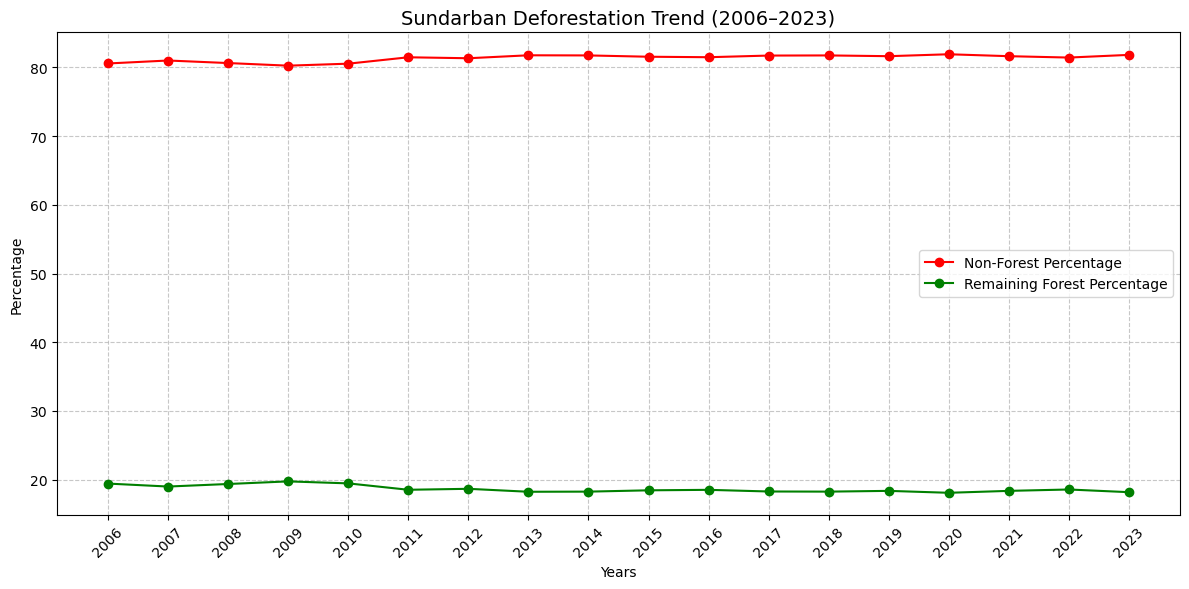

In [5]:
import matplotlib.pyplot as plt

years = [
    '2006', '2007', '2008', '2009', '2010', '2011', '2012',
    '2013', '2014', '2015', '2016', '2017', '2018',
    '2019', '2020', '2021', '2022', '2023'
]

non_forest_percentages = [
    80.57, 81.00, 80.63, 80.25, 80.54, 81.47, 81.33,
    81.76, 81.74, 81.55, 81.48, 81.72, 81.74,
    81.63, 81.91, 81.63, 81.43, 81.82
]

remaining_forest_percentages = [
    19.43, 19.00, 19.37, 19.75, 19.46, 18.53, 18.67,
    18.24, 18.26, 18.45, 18.52, 18.28, 18.26,
    18.37, 18.09, 18.37, 18.57, 18.18
]



# Plotting
plt.figure(figsize=(12, 6))
plt.plot(years, non_forest_percentages, marker='o', label='Non-Forest Percentage', color='red')
plt.plot(years, remaining_forest_percentages, marker='o', label='Remaining Forest Percentage', color='green')

plt.title('Sundarban Deforestation Trend (2006–2023)', fontsize=14)
plt.xlabel('Years')
plt.ylabel('Percentage')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [6]:
import tensorflow as tf
size = 256
# Load the pre-trained U-Net model
model = load_model('forest_detection_model_vgg16_unet_21042025i2.h5')

def scaleStd(x):
    return (x - (np.nanmean(x) - np.nanstd(x) * 2)) / ((np.nanmean(x) + np.nanstd(x) * 2) - (np.nanmean(x) - np.nanstd(x) * 2))

def preprocess_input(image):
    # Assuming pixel values are in the range [0, 255]
    image = image / 255.0
    return image

def calculate_deforestation_per_year(image_paths, tile_size=size):
    num_years = len(image_paths)
    
    deforestation_percentages = []
    forest_percentages = []
    
    for i in range(num_years):
        # Preprocess the image and split into tiles
        tiles = preprocess_image(image_paths[i], tile_size)

        # Predict using the trained model for all tiles
        predictions = [model.predict(np.expand_dims(tile, axis=0)) for tile in tiles]

        # Calculate the percentage of non-forest for each tile
        deforestation_percentages_i = []
        for prediction in predictions:
            sum_prediction = np.sum(prediction, axis=-1)
            
            # Calculate the percentage of non-forest (deforestation)
            non_zero_mask = sum_prediction != 0
            deforestation_percentage = np.zeros_like(sum_prediction)
            deforestation_percentage[non_zero_mask] = (
                sum_prediction[non_zero_mask] / sum_prediction[non_zero_mask].max()
            ) * 100

            deforestation_percentages_i.append(np.nanmean(deforestation_percentage))

        # Calculate overall deforestation and forest percentage for the year
        avg_deforestation = np.nanmean(deforestation_percentages_i)
        deforestation_percentages.append(avg_deforestation)
        forest_percentages.append(100 - avg_deforestation)

    return deforestation_percentages, forest_percentages


def visualize_deforestation(image_paths):
    deforestation_percentages, forest_percentages = calculate_deforestation_per_year(image_paths)

    for i, image_path in enumerate(image_paths):
        year = extract_year_from_filename(os.path.basename(image_path))

        deforestation_text = f"Non-Forest Percentage - {year}: {deforestation_percentages[i]:.2f}%"
        forest_text = f"Remaining Forest Percentage - {year}: {forest_percentages[i]:.2f}%"
        
        print(deforestation_text)
        print(forest_text)


def extract_year_from_filename(filename):
    # Extract the last 4 digits from the filename
    match = re.search(r'\d{4}', filename)
    if match:
        return int(match.group())
    else:
        return None
    
def preprocess_image(image_path, tile_size=size):
    # Load the image using rasterio for specific band access
    with rasterio.open(image_path) as src:
        red = src.read(1, masked=True)
        green = src.read(2, masked=True)
        blue = src.read(3, masked=True)

    # Normalize bands
    r_std = scaleStd(red)
    g_std = scaleStd(green)
    b_std = scaleStd(blue)

    # Stack normalized bands into RGB image
    rgb_std = np.dstack((r_std, g_std, b_std))

    # Convert to float32 and scale to 0–255
    rgb_std = np.clip(rgb_std, 0, 1)  # Make sure values are within range
    rgb_std = (rgb_std * 255).astype(np.uint8)

    img_height, img_width, _ = rgb_std.shape

    # Split into tiles
    tiles = []
    for y in range(0, img_height, tile_size):
        for x in range(0, img_width, tile_size):
            tile = rgb_std[y:y+tile_size, x:x+tile_size, :]
            tiles.append(tile)

    # Pad tiles with zeros to match maximum height/width
    max_width = max(tile.shape[1] for tile in tiles)
    max_height = max(tile.shape[0] for tile in tiles)
    padded_tiles = [
        np.pad(tile, ((0, max_height - tile.shape[0]), (0, max_width - tile.shape[1]), (0, 0)), 'constant')
        for tile in tiles
    ]

    # Preprocess for model input
    preprocessed_tiles = [preprocess_input(img_to_array(tile)) for tile in padded_tiles]

    return preprocessed_tiles


# Provide the directory containing satellite images for different years
image_directory = "testimage/sund/landsat_8_normalized/2024-2025"
image_paths = [os.path.join(image_directory, filename) for filename in os.listdir(image_directory) if filename.endswith(".tif")]

# Visualize deforestation on the original images without showing the map
visualize_deforestation(image_paths)

1/1 [==============================] - 1s 540ms/step


1/1 [==============================] - 1s 606ms/step


1/1 [==============================] - 1s 591ms/step
Non-Forest Percentage - 2024: 81.62%
Remaining Forest Percentage - 2024: 18.38%
Non-Forest Percentage - 2025: 81.97%
Remaining Forest Percentage - 2025: 18.03%


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.32 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=15.762, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=17.530, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=17.091, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14.530, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.11 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.567 seconds

Selected ARIMA order: (0, 1, 0)


C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


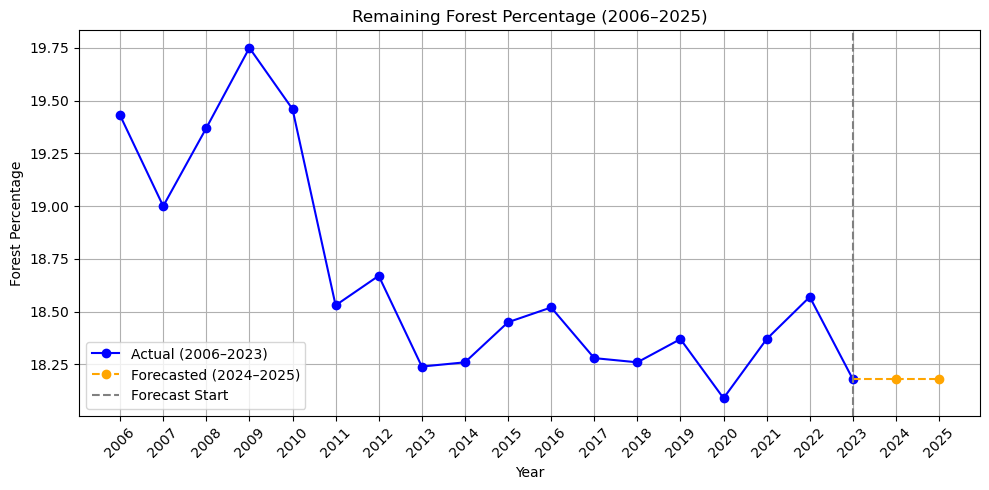


Actual vs Forecasted (2024–2025):
2024: Forecast = 18.18%, Actual = 18.38%, Difference = 0.20% (a small gap)
2025: Forecast = 18.18%, Actual = 18.03%, Difference = 0.15% (a small gap)


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

# Forest percentage data from 2006 to 2023
years = list(range(2006, 2024))
forest_percentages = [
    19.43, 19.00, 19.37, 19.75, 19.46, 18.53, 18.67,
    18.24, 18.26, 18.45, 18.52, 18.28, 18.26,
    18.37, 18.09, 18.37, 18.57, 18.18
]

# Actual values for 2024 and 2025
actual_future_years = [2024, 2025]
actual_future_values = [18.38, 18.03]

# Create pandas Series for time series modeling
forest_series = pd.Series(forest_percentages, index=pd.Index(years, name="Year"))

# Use auto_arima to find best order (p, d, q)
stepwise_model = auto_arima(
    forest_series, seasonal=False, trace=True,
    error_action='ignore', suppress_warnings=True, stepwise=True
)
print(f"\nSelected ARIMA order: {stepwise_model.order}")

# Fit ARIMA model
model = ARIMA(forest_series, order=stepwise_model.order)
model_fit = model.fit()

# Forecast for 2024 and 2025
forecast_years = [2024, 2025]
forecast = model_fit.forecast(steps=2)
forecast_series = pd.Series(forecast.values, index=forecast_years)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(forest_series.index, forest_series.values, marker='o', color='blue', label='Actual (2006–2023)')
plt.plot(forecast_series.index, forecast_series.values, marker='o', linestyle='--', color='orange', label='Forecasted (2024–2025)')

# Optional: Connect last actual (2023) to first forecast (2024)
plt.plot([2023, 2024], [forest_series[2023], forecast_series[2024]], color='orange', linestyle='--')

# Mark forecast starting point
plt.axvline(x=2023, linestyle='--', color='gray', label='Forecast Start')

plt.title("Remaining Forest Percentage (2006–2025)")
plt.xlabel("Year")
plt.ylabel("Forest Percentage")
plt.xticks(ticks=range(2006, 2026), rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Print comparison
print("\nActual vs Forecasted (2024–2025):")
for i, year in enumerate(forecast_years):
    forecast_val = forecast_series[year]
    actual_val = actual_future_values[i]
    diff = abs(forecast_val - actual_val)
    comment = "very close!" if diff < 0.05 else "a small gap"
    print(f"{year}: Forecast = {forecast_val:.2f}%, Actual = {actual_val:.2f}%, Difference = {diff:.2f}% ({comment})")


Selected ARIMA order: (0, 1, 0)


C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


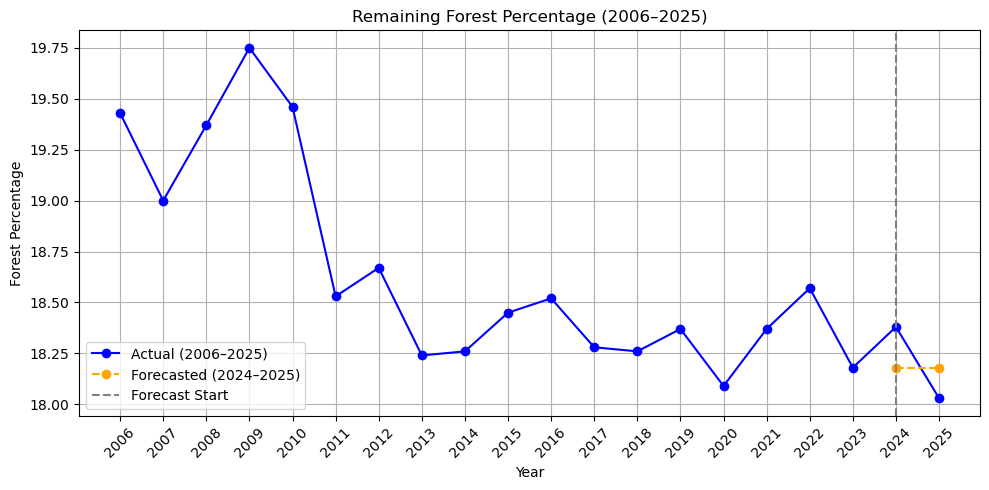


Actual vs Forecasted (2024–2025):
2024: Forecast = 18.18%, Actual = 18.38%, Difference = 0.20% (a small gap)
2025: Forecast = 18.18%, Actual = 18.03%, Difference = 0.15% (a small gap)


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

# Actual forest percentage data from 2006 to 2025
years = list(range(2006, 2026))
forest_percentages = [
    21.18, 21.42, 21.46, 22.19, 21.50, 21.51, 22.44,
    20.07, 18.78, 18.17, 19.11, 18.71, 19.25,
    18.69, 18.96, 18.81, 18.87, 18.91, 18.92, 18.42  # includes 2024, 2025 actual
]

forest_percentages = [
    19.43, 19.00, 19.37, 19.75, 19.46, 18.53, 18.67,
    18.24, 18.26, 18.45, 18.52, 18.28, 18.26,
    18.37, 18.09, 18.37, 18.57, 18.18, 18.38, 18.03
]

# Separate actual data for modeling (up to 2023)
training_years = list(range(2006, 2024))
training_data = forest_percentages[:len(training_years)]

# Fit the ARIMA model on training data
forest_series = pd.Series(training_data, index=pd.Index(training_years, name="Year"))
stepwise_model = auto_arima(
    forest_series, seasonal=False, trace=False,
    error_action='ignore', suppress_warnings=True, stepwise=True
)
print(f"Selected ARIMA order: {stepwise_model.order}")

model = ARIMA(forest_series, order=stepwise_model.order)
model_fit = model.fit()

# Forecast for 2024 and 2025
forecast_years = [2024, 2025]
forecast = model_fit.forecast(steps=2)
forecast_series = pd.Series(forecast.values, index=forecast_years)

# Plotting both actual (including 2024–2025) and forecasted
plt.figure(figsize=(10, 5))

# Full actual data including 2024 & 2025
plt.plot(years, forest_percentages, marker='o', color='blue', label='Actual (2006–2025)')

# Forecasted values for 2024–2025
plt.plot(forecast_series.index, forecast_series.values, marker='o', linestyle='--', color='orange', label='Forecasted (2024–2025)')

# Forecast start line
plt.axvline(x=2024, linestyle='--', color='gray', label='Forecast Start')

plt.title("Remaining Forest Percentage (2006–2025)")
plt.xlabel("Year")
plt.ylabel("Forest Percentage")
plt.xticks(ticks=range(2006, 2026), rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Print forecast vs actual comparison
print("\nActual vs Forecasted (2024–2025):")

actual_future_values = [18.38, 18.03]
for i, year in enumerate(forecast_years):
    forecast_val = forecast_series[year]
    actual_val = actual_future_values[i]
    diff = abs(forecast_val - actual_val)
    comment = "very close!" if diff < 0.05 else "a small gap"
    print(f"{year}: Forecast = {forecast_val:.2f}%, Actual = {actual_val:.2f}%, Difference = {diff:.2f}% ({comment})")


In [11]:
import pandas as pd
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

# Forest percentage data from 2006 to 2023
years = list(range(2006, 2024))
remaining_forest_percentages = [
    19.43, 19.00, 19.37, 19.75, 19.46, 18.53, 18.67,
    18.24, 18.26, 18.45, 18.52, 18.28, 18.26,
    18.37, 18.09, 18.37, 18.57, 18.18
]

# Create time series
forest_series = pd.Series(remaining_forest_percentages, index=pd.Index(years, name="Year"))

# Use auto_arima to find the best (p, d, q)
stepwise_model = auto_arima(
    forest_series, seasonal=False, trace=False,
    error_action='ignore', suppress_warnings=True, stepwise=True
)

# Fit ARIMA model
model = ARIMA(forest_series, order=stepwise_model.order)
model_fit = model.fit()

# Forecast for 2024 and 2025
forecast = model_fit.forecast(steps=2)
forecast_years = [2024, 2025]
forecast_series = pd.Series(forecast.values, index=forecast_years)

stepwise_model.order, forecast_series


C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


((0, 1, 0),
 2024    18.18
 2025    18.18
 dtype: float64)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.26 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=15.762, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=17.530, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=17.091, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14.530, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.12 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.499 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   18
Model:               SARIMAX(0, 1, 0)   Log Likelihood                  -6.265
Date:                Mon, 21 Apr 2025   AIC                             14.530
Time:                        20:13:32   BIC                             15.364
Sample:                             0   HQIC                            14.613
                            

C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


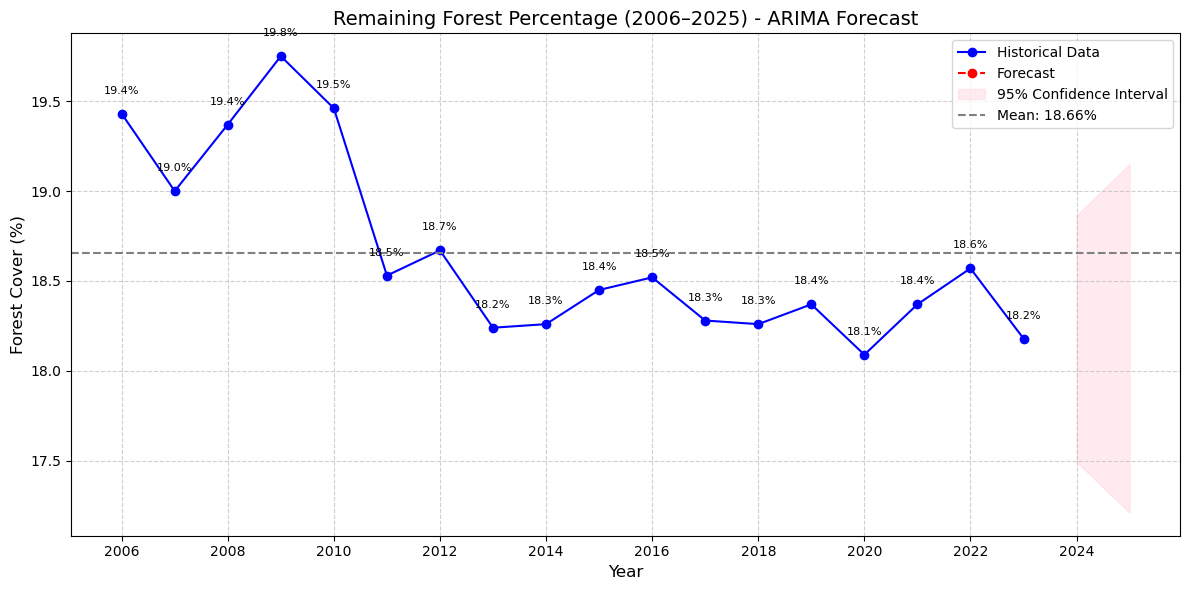

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima

# Data
years = list(range(2006, 2024))
forest_pct = [19.43, 19.00, 19.37, 19.75, 19.46, 18.53, 18.67, 
              18.24, 18.26, 18.45, 18.52, 18.28, 18.26, 18.37, 
              18.09, 18.37, 18.57, 18.18]

# Create a DataFrame
df = pd.DataFrame({'Year': years, 'Forest_Pct': forest_pct})
df.set_index('Year', inplace=True)

# Fit Auto ARIMA
model = auto_arima(df['Forest_Pct'], seasonal=False, trace=True,
                   suppress_warnings=True, stepwise=True,
                   error_action='ignore')

print(model.summary())

# Forecast 2024-2025
forecast, conf_int = model.predict(n_periods=2, return_conf_int=True)
forecast_years = [2024, 2025]
forecast_series = pd.Series(forecast, index=forecast_years)
lower_bound = pd.Series(conf_int[:, 0], index=forecast_years)
upper_bound = pd.Series(conf_int[:, 1], index=forecast_years)

# Plotting
plt.figure(figsize=(12, 6))
plt.title('Remaining Forest Percentage (2006–2025) - ARIMA Forecast', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Forest Cover (%)', fontsize=12)

# Historical data
plt.plot(df.index, df['Forest_Pct'], 'bo-', label='Historical Data')

# Forecast
plt.plot(forecast_series.index, forecast_series, 'ro--', label='Forecast')
plt.fill_between(forecast_years, lower_bound, upper_bound, 
                 color='pink', alpha=0.3, label='95% Confidence Interval')

# Annotations
for year, pct in zip(df.index, df['Forest_Pct']):
    plt.text(year, pct + 0.1, f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

for year, pct in zip(forecast_series.index, forecast_series):
    plt.text(year, pct + 0.1, f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

plt.axhline(y=df['Forest_Pct'].mean(), color='gray', linestyle='--', 
            label=f'Mean: {df["Forest_Pct"].mean():.2f}%')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(np.arange(2006, 2026, 2))
plt.tight_layout()
plt.show()

Selected ARIMA order: (0, 1, 0)


C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


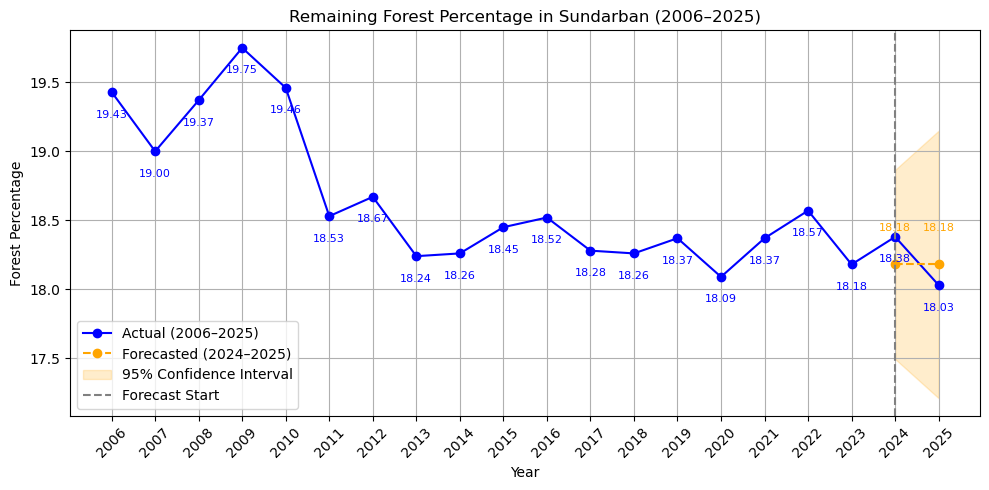


Actual vs Forecasted (2024–2025):
2024: Forecast = 18.18%, Actual = 18.38%, CI = [17.49, 18.87], Difference = 0.20% (a small gap)
2025: Forecast = 18.18%, Actual = 18.03%, CI = [17.21, 19.15], Difference = 0.15% (a small gap)


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

# Actual remaining forest percentage data from 2006 to 2025
years = list(range(2006, 2026))
remaining_forest_percentages = [
    19.43, 19.00, 19.37, 19.75, 19.46, 18.53, 18.67,
    18.24, 18.26, 18.45, 18.52, 18.28, 18.26,
    18.37, 18.09, 18.37, 18.57, 18.18, 18.38, 18.03  # includes 2024, 2025 actual
]

# Separate actual data for modeling (up to 2023)
training_years = list(range(2006, 2024))
training_data = remaining_forest_percentages[:len(training_years)]

# Fit the ARIMA model on training data
forest_series = pd.Series(training_data, index=pd.Index(training_years, name="Year"))
stepwise_model = auto_arima(
    forest_series, seasonal=False, trace=False,
    error_action='ignore', suppress_warnings=True, stepwise=True
)
print(f"Selected ARIMA order: {stepwise_model.order}")

model = ARIMA(forest_series, order=stepwise_model.order)
model_fit = model.fit()

# Forecast for 2024 and 2025 with confidence intervals
forecast_years = [2024, 2025]
forecast_result = model_fit.get_forecast(steps=2)
forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

forecast_series = pd.Series(forecast.values, index=forecast_years)

# Plotting both actual (including 2024–2025) and forecasted
plt.figure(figsize=(10, 5))

# Full actual data including 2024 & 2025
plt.plot(years, remaining_forest_percentages, marker='o', color='blue', label='Actual (2006–2025)')
for x, y in zip(years, remaining_forest_percentages):
    plt.text(x, y - 0.2, f'{y:.2f}', ha='center', va='bottom', fontsize=8, color='blue')

# Forecasted values for 2024–2025
plt.plot(forecast_series.index, forecast_series.values, marker='o', linestyle='--', color='orange', label='Forecasted (2024–2025)')
for x, y in zip(forecast_series.index, forecast_series.values):
    plt.text(x, y + 0.3, f'{y:.2f}', ha='center', va='top', fontsize=8, color='orange')

# Plot confidence intervals
plt.fill_between(forecast_years,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='orange', alpha=0.2, label='95% Confidence Interval')

# Forecast start line
plt.axvline(x=2024, linestyle='--', color='gray', label='Forecast Start')

plt.title("Remaining Forest Percentage in Sundarban (2006–2025)")
plt.xlabel("Year")
plt.ylabel("Forest Percentage")
plt.xticks(ticks=range(2006, 2026), rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Print forecast vs actual comparison
print("\nActual vs Forecasted (2024–2025):")
actual_future_values = [18.38, 18.03]
for i, year in enumerate(forecast_years):
    forecast_val = forecast_series[year]
    actual_val = actual_future_values[i]
    lower, upper = conf_int.iloc[i]
    diff = abs(forecast_val - actual_val)
    comment = "very close!" if diff < 0.05 else "a small gap"
    print(f"{year}: Forecast = {forecast_val:.2f}%, Actual = {actual_val:.2f}%, "
          f"CI = [{lower:.2f}, {upper:.2f}], Difference = {diff:.2f}% ({comment})")
